In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [4]:
load_dotenv()

True

In [5]:
model = ChatGroq(
    model = 'llama-3.3-70b-versatile'
)

In [16]:
class BLOGstate(TypedDict):
    title:str
    outline:str
    content:str
    score:float

In [7]:
def create_outline(state:BLOGstate) -> BLOGstate:
    title = state['title']

    prompt =f'Make a outline for the following title : {title}'
    outline = model.invoke(prompt).content

    state['outline']=outline
    return state

In [8]:
def create_content(state: BLOGstate)->BLOGstate:
    title = state['title']
    outline = state['outline']

    prompt = f'Make a blog with the title of : {title} having outline : {outline}'
    content = model.invoke(prompt).content

    state['content'] = content

    return state 

In [25]:
def evaluate_blog(state: BLOGstate)->BLOGstate:
    title=state['title']
    outline = state['outline']
    content= state['content']

    prompt = f'Give score from 1 to 10 for \n title : {title}, \n having outline : {outline} \n and having content : {content}'
    score = model.invoke(prompt)

    state['score'] = score
    return state

In [27]:
graph = StateGraph(BLOGstate)

graph.add_node('create_outline', create_outline)
graph.add_node('create_content', create_content)
graph.add_node('evaluate_blog', evaluate_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_content')
graph.add_edge('create_content', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

workflow = graph.compile()

In [28]:
initial_state = {'title':'What is the curent political situation of Pakistan?'}
final_state  = workflow.invoke(initial_state)

In [29]:
print(final_state['score'])

content="I would give this content a score of 8 out of 10. Here's why:\n\n**Strengths:**\n\n1. **Comprehensive outline**: The outline provided is detailed and covers all the essential aspects of the current political situation in Pakistan.\n2. **Well-structured content**: The content follows the outline and is well-organized, making it easy to read and understand.\n3. **Good introduction**: The introduction provides a brief overview of Pakistan's history and politics, setting the stage for the rest of the content.\n4. **In-depth analysis**: The content provides a thorough analysis of the current government, major political issues, political parties, and regional and international relations.\n5. **Objective tone**: The content maintains a neutral tone, presenting facts and information without taking a biased stance.\n\n**Weaknesses:**\n\n1. **Lack of depth in some areas**: Some sections, such as the discussion on social issues and human rights, could be more detailed and nuanced.\n2. **

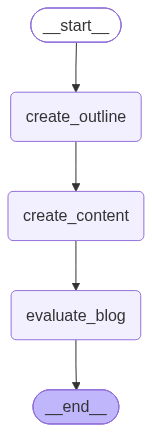

In [30]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())